In [1]:
!pip install pykeops
!pip install -qq "git+https://github.com/christpaul94/MD1912.git#subdirectory=MolecularDynamics"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 36.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 25.5 MB/s eta 0:00:00
  Created wheel for pykeops: filename=pykeops-2.3-py3-none-any.whl size=120491 sha256=08f45c0ad8a379927c928d8d1df8ea880bb1ddc94dc2cf35e55ee35e7e119100
  Stored in directory: /root/.cache/pip/wheels/b0/ac/34/a732caf88f9754536a4e2389a3f08c035ad33c0ae6f4cfbc38
  Created wheel for keopscore: filename=keopscore-2.3-py3-none-any.whl size=185897 sha256=6f3365314be9dedf53fca5ae696788dade541dda14c602215ecb35813f7ba8e7
  Stored in directory: /root/.cache/pip/wheels/4f/f8/36/9335901e1bdbd1b6c466d8f33800f66f09c60e457ebc921d29
Successfully built pykeops keopscore
  Preparing metadata (setup.py) ... done


In [2]:
# Algorithm: Triton Simple N-Body Kernel
# Input: Positions Q, Parameters (V0, sigma)
# Output: Forces F

# Parallel for each particle i from 0 to N-1 (Grid ID):
#     // 1. Load data to registers
#     Load q_i from Global Memory into Registers
#     Initialize Accumulator F_i = (0, 0, 0)

#     // 2. Stream neighbor particles in blocks
#     For j_start from 0 to N with step BLOCK_SIZE:
#         // Load a block of j particles
#         Load Q_block from Global Memory [j_start : j_start + BLOCK_SIZE]

#         // Vectorized computation in Registers
#         Calculate distance vectors D = q_i - Q_block
#         Calculate squared distances R2 = sum(D^2)
#         Calculate Force Magnitude M = exp(-R2 / (2*sigma^2)) * (V0/sigma^2)

#         // Accumulate
#         F_i += sum(D * M)

#     // 3. Store result
#     Store F_i to Global Memory

--- SCALING BENCHMARK ---
Device: cuda
N Werte: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]

Benchmarking N=2...
Benchmarking N=4...
Benchmarking N=8...
Benchmarking N=16...
Benchmarking N=32...
Benchmarking N=64...
Benchmarking N=128...
Benchmarking N=256...
Benchmarking N=512...
Benchmarking N=1024...
Benchmarking N=2048...
Benchmarking N=4096...
Benchmarking N=8192...
Benchmarking N=16384...
Benchmarking N=32768...
Benchmarking N=65536...
Benchmarking N=131072...
Benchmarking N=262144...

Erstelle Plot 


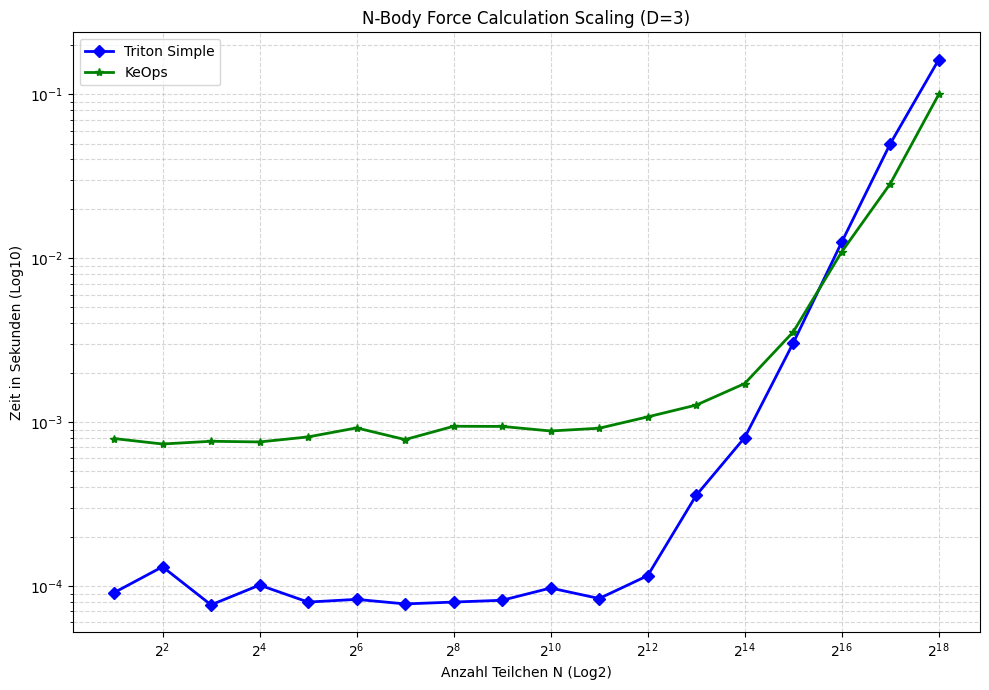

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import gc
import numpy as np

# Import deiner Funktionen
# (Stelle sicher, dass der Pfad korrekt ist, sonst nimm "nbody_force_kernels" ohne den Ordner davor)
from TrappedAtomsSimulation.nbody_force_kernels import (
    loop_DxN,
    naive_DxN,
    pytorch_chunked_DxN,
    triton_simple_DxN,
    keops_DxN
)

# --- KONFIGURATION ---
torch.set_float32_matmul_precision('high')
device = 'cuda'
D = 3
r0 = 1.0
c = 1.0

# Wir testen N von 2^10 (1024) bis 2^18 (262.144)
# Pass die Liste an, falls du noch höher gehen willst (z.B. bis 2^20 für KeOps Stress-Test)
N_list = [2**x for x in range(1, 19)]

# --- ALGORITHMEN ---
algos = [
    # (Name, Funktion, Farbe, Marker)
    #("Python Loop",     loop_DxN,            "red",    "x"),
    #("PyTorch Naive",   naive_DxN,           "brown",  "o"),
    #("PyTorch Chunked", pytorch_chunked_DxN, "gray",   "s"),
    ("Triton Simple",   triton_simple_DxN,   "blue",   "D"),
    ("KeOps",           keops_DxN,           "green",  "*"),
]

print(f"--- SCALING BENCHMARK ---")
print(f"Device: {device}")
print(f"N Werte: {N_list}\n")

results = []

# --- HAUPTSCHLEIFE ÜBER N ---
for N in N_list:
    print(f"Benchmarking N={N}...")

    # Daten generieren (jedes Mal neu, um Speicherfragmentierung zu minimieren)
    try:
        q = torch.randn(D, N, device=device, dtype=torch.float32)
    except RuntimeError:
        print(f"  -> OOM beim Erstellen von q für N={N}!")
        break

    for name, func, color, marker in algos:
        # 1. SKIP LOGIK (Damit wir nicht ewig warten oder crashen)
        if "Loop" in name and N > 4096:
            continue # Loop ist O(N^2) in Python -> zu langsam
        if "Naive" in name and N > 8192:
            continue # Naive braucht O(N^2) Speicher -> OOM Gefahr

        # Garbage Collection
        gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

        # Chunk Wahl
        if "Chunked" in name:
            # Bei sehr großem N muss der Chunk kleiner werden oder konstant bleiben
            c_size = 2**10
        else:
            c_size = None

        # Messung
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        runs = 1 #if ("Loop" in name or "Naive" in name) else 5

        try:
            # Warmup (nur 1x)
            func(q, r0, c, chunk=c_size)
            torch.cuda.synchronize()

            # Timing
            start_event.record()
            for _ in range(runs):
                func(q, r0, c, chunk=c_size)
            end_event.record()
            torch.cuda.synchronize()

            t_sec = (start_event.elapsed_time(end_event) / runs) / 1000.0

            results.append({
                "N": N,
                "Algo": name,
                "Time": t_sec,
                "Color": color,
                "Marker": marker
            })
            # Kurzes Feedback in der Konsole
            # print(f"  -> {name}: {t_sec:.5f}s")

        except RuntimeError as e:
            print(f"  -> {name}: OOM (Out of Memory)")
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  -> {name}: Fehler {e}")

    # q löschen für den nächsten Durchlauf
    del q

# --- PLOTTING ---
print("\nErstelle Plot ")
df = pd.DataFrame(results)

plt.figure(figsize=(10, 7))

for name in df["Algo"].unique():
    subset = df[df["Algo"] == name]
    color = subset.iloc[0]["Color"]
    marker = subset.iloc[0]["Marker"]

    plt.plot(subset["N"], subset["Time"], label=name, color=color, marker=marker, linewidth=2)

plt.xscale('log', base=2)
plt.yscale('log', base=10)

plt.xlabel("Anzahl Teilchen N (Log2)")
plt.ylabel("Zeit in Sekunden (Log10)")
plt.title(f"N-Body Force Calculation Scaling (D={D})")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)


plt.tight_layout()
plt.show()